# Sun Indexing:

This notebook is about learning how to index a particular day over the sun as the sun is a fixed radio source that is used to calibrate the data from engenierring units to physical units.  Here, I fit a gaussian fit into raw data and allow the user to write in a frequency channel to where the data will be taken.  

The process to getting here required learning how to zoom into a specific point in the data, convert it into the correct units, and preforming a curve fit on the data to compare it to the raw data.  This is mainly useful for the following channels: 410 and 610 MHz.  This is because according to the United States Frequency Allocation spectrum, Radio Astronomy observing is reserved at channels 410 and 610.  Therefore at these channels, RFI is reduced for observation. 

2025-01-21 20:00:14.681796+00:00
17822383.551222812


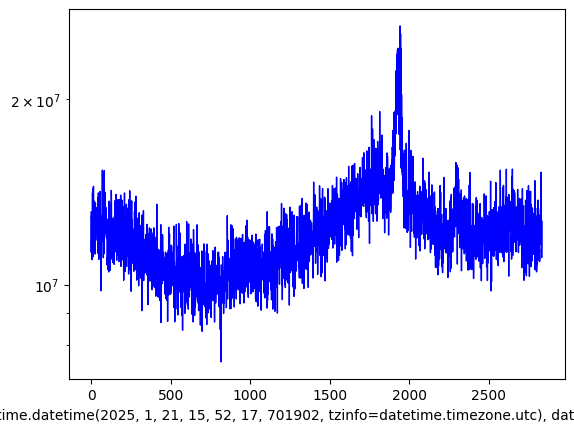

In [1]:
#imports
#Identify the sun passing though the chime beam

import numpy as np
import matplotlib.pyplot as plt
import chime

#loading data from chime archive

sample_data = "/home/scratch/dbautist/CHIME_archive/2025_021"
chime.calibration.load_CHIME_data(sample_data)
chime_data, frequency, timestamps = chime.calibration.load_CHIME_data(sample_data)

print(timestamps[1913])

plt.xlabel(timestamps)

plt.semilogy(chime_data[:,25], color='blue', linewidth=1)
print(chime_data[1913,450])


frequency index:537
value at 610.15625MHZ 2025-01-21 20:00:14.681796+00:00: 15173725.846098252


Text(0.5, 1.0, 'Average spectrum vs. frequency')

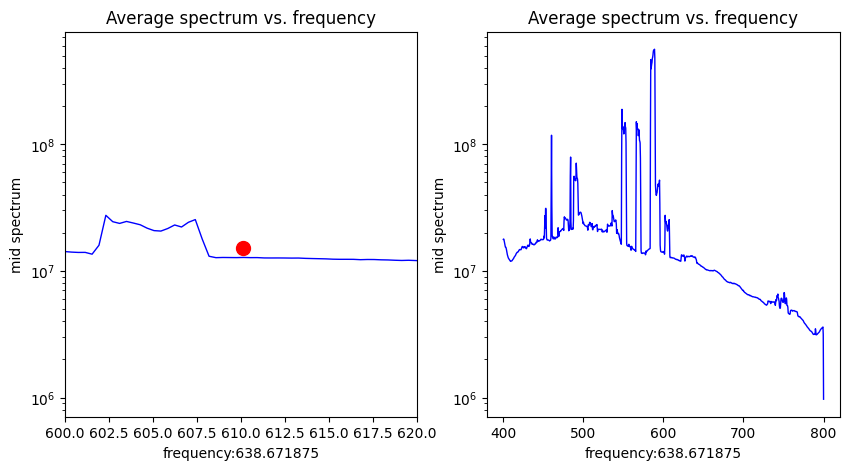

In [2]:

targ_freq = 610

time_indx = 1913

mid_spectrum = np.median(chime_data, axis=0)

freq_ind = np.argmin(np.abs(frequency - targ_freq))
print(f'frequency index:{freq_ind}')
values = chime_data[time_indx, freq_ind]
print(f'value at {frequency[freq_ind]}MHZ {timestamps[time_indx]}: {values}')

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10,5), sharex='col') #for multiple graphs to exist

ax1.semilogy(frequency, mid_spectrum, color="blue", linewidth=1)
ax1.semilogy(frequency[freq_ind], values, 'ro', markersize=10, label=f't={timestamps[time_indx]}')

freq_window =10.0

ax1.set_xlabel(f"frequency:{frequency[targ_freq]}")
ax1.set_ylabel("mid spectrum")
ax1.set_title("Average spectrum vs. frequency")
ax1.set_xlim(targ_freq - freq_window, targ_freq + freq_window)

ax2.semilogy(frequency, mid_spectrum, color="blue", linewidth=1)
ax2.set_xlabel(f"frequency:{frequency[targ_freq]}")
ax2.set_ylabel("mid spectrum")
ax2.set_title("Average spectrum vs. frequency")

# zooming into the data:

In this program, I learn to zoom up at a specific indicy to between 1870 and 2000 out of 2521 timestamps.

410.15625


(1870.0, 2000.0)

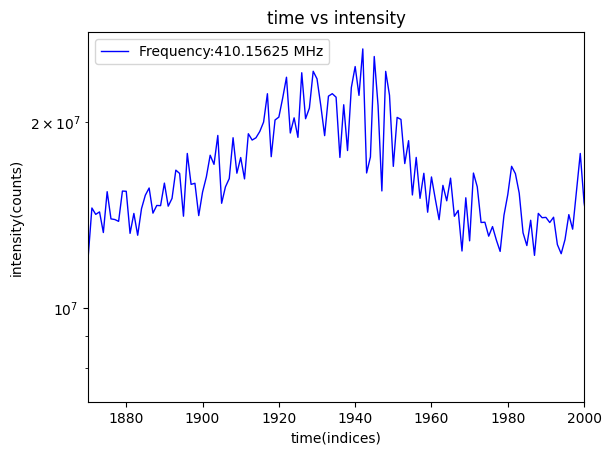

In [3]:

plt.figure()

print(frequency[25]) #at 410

plt.semilogy(chime_data[:, 25], color="blue", linewidth=1, label=f"Frequency:{frequency[25]} MHz")
'''plt.semilogy(chime_data[:, 537], color='red', linewidth=1, label=f'Frequency:{frequency[537]} MHz')'''

plt.legend()

plt.xlabel("time(indices)")
plt.ylabel("intensity(counts)")
plt.title("time vs intensity")

#zooming in

plt.xlim(1870, 2000)



#for conversion


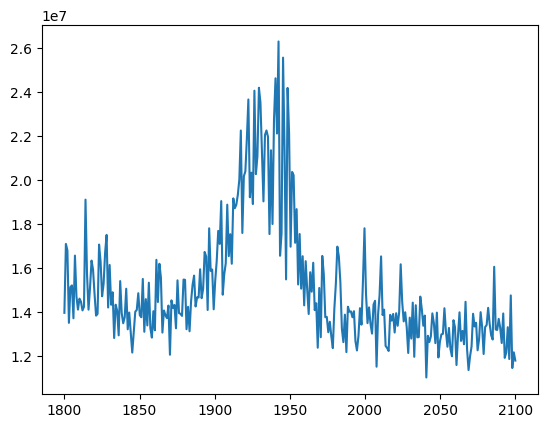

In [4]:
start = 1800
stop = 2100

y = chime_data[start:stop, 25]
x = np.linspace(start, stop, num=len(y))

plt.figure()
plt.plot(x, y)



In [5]:
#calibration stuff(from engeneering units to Jy and seconds(time))

median_410 = np.median(chime_data[:,25])
print(f'median at 410 MHz: {median_410}')

median_610 = np.median(chime_data[:,537])
print(f'median at 610MHz: {median_610}')

median at 410 MHz: 11946590.620730905
median at 610MHz: 12760687.524611644


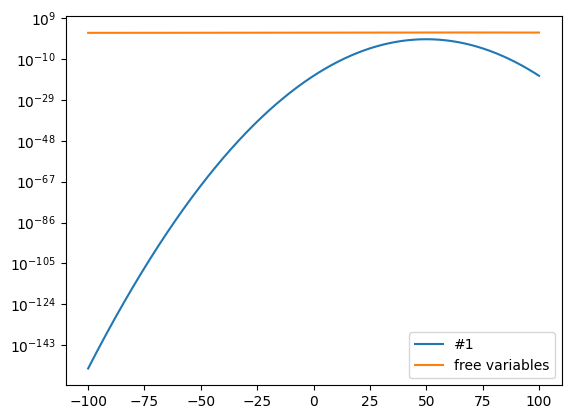

In [6]:
#gaussian fit of some random data:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = np.linspace(-100, 100, num=1000)

#function model:

def gaus(x, standard_dev, med):
    return 1 / (standard_dev * np.sqrt((2*np.pi)))*np.exp(-(x-med)**2 / (2*standard_dev)**2)

def gaus2(x, a, u, q, d):
    return a * np.exp(-(x-u)**2/(q)**2) + d

plt.figure()
plt.semilogy(x, gaus(x, standard_dev=4, med=50), label='#1')
plt.semilogy(x, gaus2(x, a=45, u=56, q=77, d=90), label='free variables')

plt.legend()

In [9]:
#now using CHIME data:

from scipy.optimize import curve_fit

#statistics:

chime_std410 = np.std(chime_data[:,25])
chime_std610 = np.std(chime_data[:,537])

x = np.linspace(-170000, 17500000, num=1000000)
print(x)

y = chime_data[:,25]
c = np.arange(y.shape[0])
n = len(c)

#functions defining the fit beam:

def gaus_CHIME610(x, b, CHIME_mid, CHIME_sd, d):
    return b * np.exp(-(x-CHIME_mid)**2/(CHIME_sd)**2)+d

#fitting raw data to graph:
'''popt, pcov = curve_fit(gaus_CHIME410, c, y)'''

# plt.figure()
# plt.plot(x, gaus_CHIME410(x, a=0.4, CHIME_mid=median_410, CHIME_sd=chime_std410), label='Plot at 410MHz')
# #plt.xlim(1870, 2000)
# #plt.plot(x, gaus_CHIME610(x, b=10, CHIME_mid=median_610, CHIME_sd=chime_std610, d=40), label='Plot at 610MHz')

# plt.legend()


[ -170000.          -169982.32998233  -169964.65996466 ...
 17499964.65996466 17499982.32998233 17500000.        ]


'popt, pcov = curve_fit(gaus_CHIME410, c, y)'

# Gaussian fit of the Sun indexed Data:

In this program, I allow the user to input at what frequency channel they would like to fit a gaussian to.  I set the start and stop times(to an indicy and the linespacing) so the user sees the indexed times of when the sun is peaking at the frequency of their choice(typically 410 and 610 MHz).  410 and 610 Mhz are important due to those channels strictly being saved for radio astronomy observations(so, CHIME telescope readings) where RFI is at a minimum at those frequencies as prompted by the United States Frequency Allocations Spectrum. 

I set an initial guess so that the data can estimate the gaussian with the raw data before defining a function to input the formula of a gaussian, yet not overlapped to 1 as then the program cannot fit it to where the raw data is, as the raw data is not distributed over 1.  From there, I preformed a curve fit so tha tthe data matches with the original data.  

I used the median and the standard devation as the median sets where the peak of the data is coming from during these timescales, which is the sun.  With the standard deviation being in control of how wide the peak of the data is.  I also added the amplitude as the amplitude is very important regarding this calcuation as it will be used to determine known values for when the calibration of the data from counts to Janskys occurs.

Amplitude will be used as a known value to figure out the conversion of JY according to the formula 
f(J)

enter an index for frequency to read25
[8.13742904e+06 1.93181780e+03 2.63843492e+01 1.38336748e+07]
errors:[3.37264820e+05 8.69391579e-01 1.32641688e+00 1.08544744e+05]
fit paramenters:[8.13742904e+06 1.93181780e+03 2.63843492e+01 1.38336748e+07]


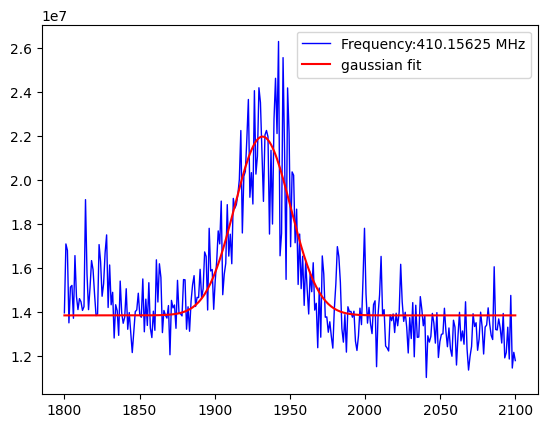

In [15]:

start = 1800
stop = 2100
#user input:

user_input = input("enter an index for frequency to read") #input statement for user to use
freq_index = int(user_input)

y = chime_data[start:stop, freq_index]
x = np.linspace(start, stop, num=len(y))

#plt.figure()
#plt.plot(x, y)

plt.figure()
def gaus_CHIME410(x, a, CHIME_mid, CHIME_sd, d):
    return a * np.exp(-(x-CHIME_mid)**2/(CHIME_sd)**2)+d

plt.plot(x, y, color="blue", linewidth=1, label=f"Frequency:{frequency[freq_index]} MHz")
#plt.xlim(1870, 2000)

#parameter guesses:

p0 = (2.4e7, 1925, 50, 1.4e7)

#fitting:

popt, pcov = curve_fit(gaus_CHIME410, x, y, p0=p0)
print(popt)

perr = np.sqrt(np.diag(pcov))
print(f'errors:{perr}')
y_fit = gaus_CHIME410(x, popt[0], popt[1], popt[2], popt[3])

plt.plot(x, y_fit, color='red', label='gaussian fit')
plt.legend()
print(f'fit paramenters:{popt}')